# Workshop: Generative AI with Diffusion Models
## Part 3: Conditional Generation and CLIP

Practical session (60 min)

This notebook is part of a workshop based on NVIDIA DLI materials
"Generative AI with Diffusion Models",
adapted for Google Colab with a T4 GPU.

Credits: Original course materials by NVIDIA Corporation / NVIDIA Deep Learning Institute.

### Learning Objectives

By the end of this notebook you will be able to:

- Add class conditioning and classifier-free guidance (CFG) to the U-Net
- Control generation by setting a class label and a guidance weight w
- Understand how CLIP encodes both text and images in the same vector space
- Generate flower images from free-form text descriptions using a CLIP-conditioned model

In [1]:
# Install CLIP (OpenAI)
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


In [2]:
import math
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from einops.layers.torch import Rearrange
from PIL import Image
import clip

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU   :', torch.cuda.get_device_name(0))

Device: cuda
GPU   : Tesla T4


---

## Part 3.1: Recap from Part 2

Run this cell to restore the noise schedule and all model building blocks.

In [3]:
# Constants
IMG_SIZE = 16
IMG_CH = 1
BATCH_SIZE = 128
T = 300

# Noise schedule
B = torch.linspace(0.0001, 0.02, T).to(device)
a = 1.0 - B
a_bar = torch.cumprod(a, dim=0)
sqrt_a_bar = torch.sqrt(a_bar)
sqrt_one_minus_a_bar = torch.sqrt(1 - a_bar)
sqrt_a_inv = torch.sqrt(1 / a)
pred_noise_coeff = (1 - a) / sqrt_one_minus_a_bar

def q(x_0, t):
    t = t.int()
    noise = torch.randn_like(x_0)
    return sqrt_a_bar[t,None,None,None]*x_0 + sqrt_one_minus_a_bar[t,None,None,None]*noise, noise

@torch.no_grad()
def reverse_q(x_t, t, e_t):
    t_int = t.int()
    u_t = sqrt_a_inv[t_int,None,None,None] * (x_t - pred_noise_coeff[t_int,None,None,None] * e_t)
    if t_int[0] == 0:
        return u_t
    return u_t + torch.sqrt(B[t_int-1,None,None,None]) * torch.randn_like(x_t)

# All optimized building blocks from Part 2
class GELUConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, gs=8):
        super().__init__()
        self.model = nn.Sequential(nn.Conv2d(in_ch,out_ch,3,1,1), nn.GroupNorm(gs,out_ch), nn.GELU())
    def forward(self, x): return self.model(x)

class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, gs=8):
        super().__init__()
        self.r = Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)
        self.c = GELUConvBlock(4*in_chs, in_chs, gs)
    def forward(self, x): return self.c(self.r(x))

class SinusoidalPositionEmbedBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        hd = self.dim//2
        f  = torch.exp(torch.arange(hd, device=t.device) * -(math.log(10000)/(hd-1)))
        e  = t[:,None] * f[None,:]
        return torch.cat((e.sin(), e.cos()), dim=-1)

class ResidualConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, gs=8):
        super().__init__()
        self.c1 = GELUConvBlock(in_ch, out_ch, gs)
        self.c2 = GELUConvBlock(out_ch, out_ch, gs)
    def forward(self, x):
        x1 = self.c1(x); return x1 + self.c2(x1)

class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.d = input_dim
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim), nn.GELU(),
            nn.Linear(emb_dim, emb_dim), nn.Unflatten(1,(emb_dim,1,1)))
    def forward(self, x): return self.model(x.view(-1,self.d))

class DownBlockOpt(nn.Module):
    def __init__(self, in_ch, out_ch, gs=8):
        super().__init__()
        self.model = nn.Sequential(GELUConvBlock(in_ch,out_ch,gs), GELUConvBlock(out_ch,out_ch,gs), RearrangePoolBlock(out_ch,gs))
    def forward(self, x): return self.model(x)

class UpBlockOpt(nn.Module):
    def __init__(self, in_ch, out_ch, gs=8):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(2*in_ch, out_ch, 2, 2),
            GELUConvBlock(out_ch,out_ch,gs), GELUConvBlock(out_ch,out_ch,gs),
            GELUConvBlock(out_ch,out_ch,gs), GELUConvBlock(out_ch,out_ch,gs))
    def forward(self, x, skip): return self.model(torch.cat((x,skip),dim=1))

print('All building blocks restored.')

All building blocks restored.


---

## Part 3.2: Adding Context Conditioning (CFG)

So far our model generates random clothing with no user control.
With **classifier-free guidance (CFG)**, we add a context vector c
that tells the model WHAT to generate.

For FashionMNIST we use a one-hot class label (10 classes).
The context is injected into the decoder: `up = UpBlock(c_emb * feature + t_emb, skip)`.

The key trick is **dropout**: during training we randomly set c to zero
with probability 10%. This trains the model to work both with and without context.

At generation time we run the model TWICE per step:
once with context, once without. We combine them with a guidance weight w:

```
noise = (1 + w) * noise_conditional - w * noise_unconditional
```

A higher w makes the output more faithful to the class label.
A lower w (even negative) pushes away from the class.

In [4]:
class UNetCFG(nn.Module):
    """Optimized U-Net with classifier-free guidance context conditioning."""
    def __init__(self, T, img_ch=1, img_size=16,
                 down_chs=(32,64,128), t_embed_dim=8, c_embed_dim=10):
        super().__init__()
        self.T = T
        up_chs = down_chs[::-1]
        lat_size = img_size // 4
        gs_sm, gs_bg = 8, 32

        self.down0 = ResidualConvBlock(img_ch, down_chs[0], gs_sm)
        self.down1 = DownBlockOpt(down_chs[0], down_chs[1], gs_sm)
        self.down2 = DownBlockOpt(down_chs[1], down_chs[2], gs_bg)
        self.to_vec = nn.Sequential(nn.Flatten(), nn.GELU())
        self.dense_emb = nn.Sequential(
            nn.Linear(down_chs[2]*lat_size**2, down_chs[1]), nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[1]), nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[2]*lat_size**2), nn.ReLU())
        self.sintime = SinusoidalPositionEmbedBlock(t_embed_dim)
        self.t_emb1 = EmbedBlock(t_embed_dim, up_chs[0])
        self.t_emb2 = EmbedBlock(t_embed_dim, up_chs[1])
        # Context embeddings (new in this class)
        self.c_emb1 = EmbedBlock(c_embed_dim, up_chs[0])
        self.c_emb2 = EmbedBlock(c_embed_dim, up_chs[1])
        self.up0 = nn.Sequential(
            nn.Unflatten(1, (up_chs[0], lat_size, lat_size)),
            GELUConvBlock(up_chs[0], up_chs[0], gs_bg))
        self.up1 = UpBlockOpt(up_chs[0], up_chs[1], gs_bg)
        self.up2 = UpBlockOpt(up_chs[1], up_chs[2], gs_sm)
        self.out = nn.Sequential(
            nn.Conv2d(2*up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.GroupNorm(gs_sm, up_chs[-1]), nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_ch, 3, 1, 1))

    def forward(self, x, t, c, c_mask):
        t_sin = self.sintime(t.float() / self.T)
        t1 = self.t_emb1(t_sin)
        t2 = self.t_emb2(t_sin)
        # Apply mask: zero out context with probability drop_prob during training
        c_emb1 = self.c_emb1(c * c_mask)
        c_emb2 = self.c_emb2(c * c_mask)
        d0 = self.down0(x)
        d1 = self.down1(d0)
        d2 = self.down2(d1)
        lat = self.dense_emb(self.to_vec(d2))
        u0 = self.up0(lat)
        # Context scales the feature map, time shifts it
        u1 = self.up1(c_emb1 * u0 + t1, d2)
        u2 = self.up2(c_emb2 * u1 + t2, d1)
        return self.out(torch.cat((u2, d0), dim=1))


def get_context_mask(c_indices, drop_prob, num_classes):
    """Convert class indices to one-hot and apply Bernoulli dropout mask."""
    c_hot = F.one_hot(c_indices.long(), num_classes=num_classes).float().to(device)
    c_mask = torch.bernoulli(torch.ones_like(c_hot) - drop_prob)
    return c_hot, c_mask


print('UNetCFG and get_context_mask defined.')

UNetCFG and get_context_mask defined.


In [5]:
# Load the 50-epoch model from Part 2 and transfer weights to UNetCFG
from google.colab import drive
drive.mount('/content/drive')

PRETRAINED_50EP = '/content/drive/MyDrive/BestCourse2026/workshop-genai/unet_50epochs.pth'

model_cfg = UNetCFG(T, img_ch=IMG_CH, img_size=IMG_SIZE,
                    down_chs=(32,64,128), c_embed_dim=10).to(device)

# Transfer matching weights from the 50-epoch model
# New layers (c_emb1, c_emb2) are left with random initialization
pretrained  = torch.load(PRETRAINED_50EP, map_location=device)
cfg_state = model_cfg.state_dict()
transferred = 0
for k, v in pretrained.items():
    if k in cfg_state and cfg_state[k].shape == v.shape:
        cfg_state[k] = v
        transferred += 1
model_cfg.load_state_dict(cfg_state)
print(f'Transferred {transferred} / {len(pretrained)} weight tensors.')
print('New context layers (c_emb1, c_emb2) are randomly initialized.')

Mounted at /content/drive
Transferred 76 / 92 weight tensors.
New context layers (c_emb1, c_emb2) are randomly initialized.


In [6]:
# Fine-tune with CFG for 3 epochs
# The model already knows clothing shapes from 50 epochs of training.
# We now teach it to respond to class labels.

# FashionMNIST class names
CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal', 'Shirt',  'Sneaker', 'Bag',  'Ankle boot']
N_CLASSES = 10
DROP_PROB = 0.1   # drop context 10% of the time during training

data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(lambda t: (t * 2) - 1),
])
train_set  = torchvision.datasets.FashionMNIST('./data', download=True, train=True,  transform=data_transforms)
test_set   = torchvision.datasets.FashionMNIST('./data', download=True, train=False, transform=data_transforms)
data = torch.utils.data.ConcatDataset([train_set, test_set])
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

optimizer = Adam(model_cfg.parameters(), lr=0.0005)
EPOCHS = 3

model_cfg.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for step, (imgs, labels) in enumerate(dataloader):
        optimizer.zero_grad()
        x_0 = imgs.to(device)
        t = torch.randint(0, T, (BATCH_SIZE,), device=device).float()
        c_hot, c_mask  = get_context_mask(labels.to(device), DROP_PROB, N_CLASSES)
        x_noisy, noise = q(x_0, t)
        loss = F.mse_loss(noise, model_cfg(x_noisy, t, c_hot, c_mask))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} | loss: {epoch_loss/len(dataloader):.5f}')

model_cfg.eval()
print('Fine-tuning done.')

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]


Epoch 1/3 | loss: 0.12310
Epoch 2/3 | loss: 0.07267
Epoch 3/3 | loss: 0.06946
Fine-tuning done.


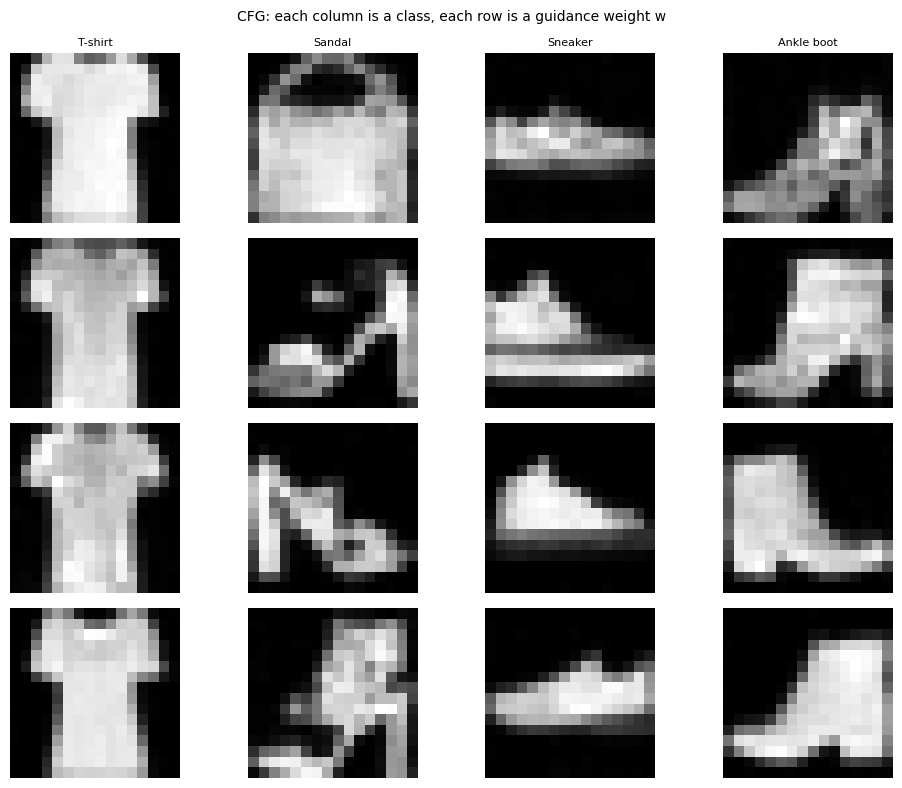

w=0.0 : no guidance (unconditional)
w=0.5 : gentle guidance
w=1.0 : standard guidance
w=2.0 : strong guidance (features exaggerated)


In [7]:
# Generate with different guidance weights
# Rows = w values, Columns = selected clothing classes

@torch.no_grad()
def sample_w(model, c_hot, w_values, img_ch=IMG_CH, img_size=IMG_SIZE, T=T):
    n_classes = len(c_hot)
    n_w = len(w_values)
    n = n_classes * n_w

    w = torch.tensor([v for v in w_values for _ in range(n_classes)])
    w = w[:, None, None, None].float().to(device)
    c = c_hot.repeat(n_w, 1)

    x_t = torch.randn(n, img_ch, img_size, img_size, device=device)

    for i in range(T - 1, -1, -1):
        t = torch.full((n,), i, device=device).float()
        # Run conditional and unconditional in one doubled batch
        x2 = x_t.repeat(2,1,1,1);  t2 = t.repeat(2)
        c2 = c.repeat(2, 1)
        m2 = torch.cat([torch.ones_like(c), torch.zeros_like(c)], dim=0)
        e2 = model(x2, t2, c2, m2)
        e_cond, e_uncond = e2[:n], e2[n:]
        e_t = (1 + w) * e_cond - w * e_uncond
        x_t = reverse_q(x_t, t, e_t)

    return x_t   # [n_w * n_classes, ch, h, w]


# Show 4 classes x 4 guidance weights
selected = [0, 5, 7, 9]   # T-shirt, Sandal, Sneaker, Ankle boot
w_values = [0.0, 0.5, 1.0, 2.0]

c_indices = torch.tensor(selected).to(device)
c_hot, _ = get_context_mask(c_indices, 0.0, N_CLASSES)

x_gen = sample_w(model_cfg, c_hot, w_values)
n_classes, n_w = len(selected), len(w_values)

fig, axes = plt.subplots(n_w, n_classes, figsize=(10, 8))
for row in range(n_w):
    for col in range(n_classes):
        idx = row * n_classes + col
        axes[row, col].imshow(((x_gen[idx]+1)/2).clamp(0,1).squeeze().cpu(), cmap='gray')
        if row == 0: axes[row, col].set_title(CLASS_NAMES[selected[col]], fontsize=8)
        if col == 0: axes[row, col].set_ylabel(f'w = {w_values[row]}', fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('CFG: each column is a class, each row is a guidance weight w', fontsize=10)
plt.tight_layout()
plt.show()

print('w=0.0 : no guidance (unconditional)')
print('w=0.5 : gentle guidance')
print('w=1.0 : standard guidance')
print('w=2.0 : strong guidance (features exaggerated)')

---

## Part 3.3: Text-to-Image with CLIP

In Part 3.2 we used a one-hot class label as the context vector.
The label had 10 dimensions, one per clothing category.

**CLIP** gives us a much richer context: a 512-dimensional vector
that represents the MEANING of any text you type.
Instead of choosing from 10 fixed labels, you can type anything.

The CLIP text encoder converts text into a vector in the same space
as image encodings. The diffusion model is trained with these CLIP vectors
as context, so it learns to generate images that match any text.

We pre-trained a flowers model with CLIP context before the workshop.
The flowers dataset has three classes: daisy, sunflower, rose.
The model architecture is the same as UNetCFG but with `c_embed_dim=512`
and trained on 32x32 RGB images.

In [8]:
# Load CLIP
clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()
CLIP_DIM = 512
print('CLIP ViT-B/32 loaded.')
print(f'Text and image encodings: {CLIP_DIM} dimensions')

100%|███████████████████████████████████████| 338M/338M [00:19<00:00, 18.3MiB/s]


CLIP ViT-B/32 loaded.
Text and image encodings: 512 dimensions


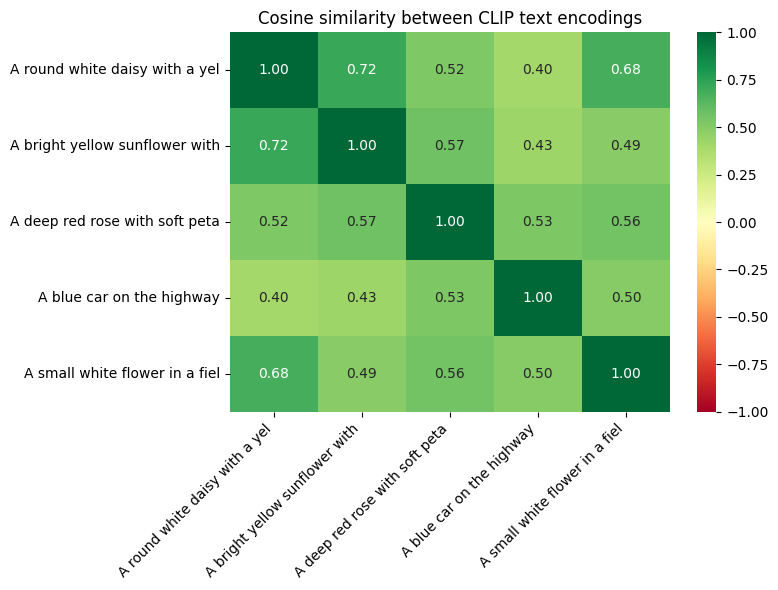

Each encoding has 512 dimensions.
The diagonal is 1.0 (each text is identical to itself).
Similar flower descriptions score higher. The car description scores low for flowers.


In [9]:
# See what CLIP text encodings look like for flower descriptions

text_descriptions = [
    'A round white daisy with a yellow center',
    'A bright yellow sunflower with a big brown center',
    'A deep red rose with soft petals',
    'A blue car on the highway',          # wrong category: should score low
    'A small white flower in a field',    # similar to daisy but vaguer
]

tokens = clip.tokenize(text_descriptions).to(device)
with torch.no_grad():
    encodings = clip_model.encode_text(tokens).float()
    encodings = encodings / encodings.norm(dim=-1, keepdim=True)

# Compute pairwise cosine similarity between text descriptions
sim = (encodings @ encodings.T).cpu().numpy()

short_labels = [t[:30] for t in text_descriptions]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sim, xticklabels=short_labels, yticklabels=short_labels,
            cmap='RdYlGn', vmin=-1, vmax=1, annot=True, fmt='.2f', ax=ax)
ax.set_title('Cosine similarity between CLIP text encodings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Each encoding has {encodings.shape[1]} dimensions.')
print('The diagonal is 1.0 (each text is identical to itself).')
print('Similar flower descriptions score higher. The car description scores low for flowers.')

Flowers loaded: 1166 images
Classes: ['daisy', 'sunflowers', 'roses']


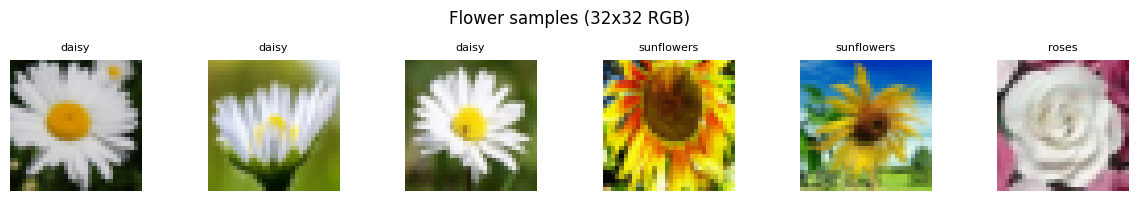

In [10]:
# Load flowers dataset from Google Drive
# The flowers are 32x32 RGB images in three subfolders: daisy, sunflowers, roses

FLOWER_SIZE = 32
FLOWER_CH = 3
FLOWER_LABELS = ['daisy', 'sunflowers', 'roses']
N_FLOWER_CLS  = len(FLOWER_LABELS)

FLOWER_DIR = '/content/drive/MyDrive/BestCourse2026/workshop-genai/data/cropped_flowers/'

flower_transforms = transforms.Compose([
    transforms.Resize((FLOWER_SIZE, FLOWER_SIZE)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(lambda t: (t * 2) - 1),
])

class FlowerDataset(Dataset):
    def __init__(self, root, labels, transform):
        self.imgs, self.labels, self.transform = [], [], transform
        for i, label in enumerate(labels):
            for path in glob.glob(f'{root}{label}/*.jpg'):
                self.imgs.append(path)
                self.labels.append(i)
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        img = Image.open(self.imgs[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]

flower_data = FlowerDataset(FLOWER_DIR, FLOWER_LABELS, flower_transforms)
flower_loader = DataLoader(flower_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f'Flowers loaded: {len(flower_data)} images')
print(f'Classes: {FLOWER_LABELS}')

# Show sample images
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axes):
    img, label = flower_data[i * (len(flower_data)//6)]
    ax.imshow(((img+1)/2).clamp(0,1).permute(1,2,0))
    ax.set_title(FLOWER_LABELS[label], fontsize=8)
    ax.axis('off')
plt.suptitle('Flower samples (32x32 RGB)')
plt.tight_layout()
plt.show()

In [11]:
# PRE-WORKSHOP: Train flowers model with CLIP conditioning
# Run this before the workshop (30 minutes on T4 for 100 epochs)

T_FLOWERS   = 300
DROP_PROB   = 0.1
EPOCHS_CLIP = 100
LR          = 1e-4

# Recompute noise schedule for flowers
B_f                    = torch.linspace(0.0001, 0.02, T_FLOWERS).to(device)
a_f                    = 1.0 - B_f
a_bar_f                = torch.cumprod(a_f, dim=0)
sqrt_a_bar_f           = torch.sqrt(a_bar_f)
sqrt_one_minus_a_bar_f = torch.sqrt(1 - a_bar_f)

def q_f(x_0, t):
    t = t.int()
    noise = torch.randn_like(x_0)
    return sqrt_a_bar_f[t,None,None,None]*x_0 + sqrt_one_minus_a_bar_f[t,None,None,None]*noise, noise

# Build model (img_ch=3, img_size=32, c_embed_dim=512 for CLIP)
model_flowers_train = UNetCFG(
    T_FLOWERS, img_ch=FLOWER_CH, img_size=FLOWER_SIZE,
    down_chs=(32, 64, 128), c_embed_dim=CLIP_DIM
).to(device)

optimizer_f = Adam(model_flowers_train.parameters(), lr=LR)

model_flowers_train.train()
for epoch in range(EPOCHS_CLIP):
    epoch_loss = 0
    for imgs, labels in flower_loader:
        optimizer_f.zero_grad()
        x_0 = imgs.to(device)
        t   = torch.randint(0, T_FLOWERS, (len(x_0),), device=device).float()

        # Get CLIP image encodings as context (use image encodings for training)
        with torch.no_grad():
            clip_imgs = torch.stack([
                clip_preprocess(Image.open(flower_data.imgs[i]).convert('RGB'))
                for i in range(len(x_0))
            ]).to(device)
            c = clip_model.encode_image(clip_imgs).float()
            c = c / c.norm(dim=-1, keepdim=True)

        # Bernoulli dropout mask
        c_mask = torch.bernoulli(torch.ones_like(c) - DROP_PROB)

        x_noisy, noise = q_f(x_0, t)
        loss = F.mse_loss(noise, model_flowers_train(x_noisy, t, c, c_mask))
        loss.backward()
        optimizer_f.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS_CLIP} | loss: {epoch_loss/len(flower_loader):.5f}')

# Save to Google Drive
import os
SAVE_PATH = '/content/drive/MyDrive/BestCourse2026/workshop-genai/flowers_clip.pth'
torch.save(model_flowers_train.state_dict(), SAVE_PATH)
print(f'Saved to {SAVE_PATH}')

Epoch 10/100 | loss: 0.40450
Epoch 20/100 | loss: 0.27135
Epoch 30/100 | loss: 0.21960
Epoch 40/100 | loss: 0.18934
Epoch 50/100 | loss: 0.19219
Epoch 60/100 | loss: 0.16131
Epoch 70/100 | loss: 0.15025
Epoch 80/100 | loss: 0.14904
Epoch 90/100 | loss: 0.15075
Epoch 100/100 | loss: 0.13069
Saved to /content/drive/MyDrive/BestCourse2026/workshop-genai/flowers_clip.pth


In [13]:
# Load the pre-trained CLIP-conditioned flowers model
# This model was trained before the workshop on flowers with CLIP context
# Architecture: UNetCFG with img_ch=3, img_size=32, c_embed_dim=512

T_FLOWERS = 300

# Recompute noise schedule for flowers (same T, same schedule)
B_f = torch.linspace(0.0001, 0.02, T_FLOWERS).to(device)
a_f = 1.0 - B_f
a_bar_f = torch.cumprod(a_f, dim=0)
sqrt_a_bar_f = torch.sqrt(a_bar_f)
sqrt_one_minus_a_bar_f = torch.sqrt(1 - a_bar_f)
sqrt_a_inv_f = torch.sqrt(1 / a_f)
pred_noise_coeff_f = (1 - a_f) / sqrt_one_minus_a_bar_f

@torch.no_grad()
def reverse_q_f(x_t, t, e_t):
    t_int = t.int()
    u_t = sqrt_a_inv_f[t_int,None,None,None] * (x_t - pred_noise_coeff_f[t_int,None,None,None] * e_t)
    if t_int[0] == 0: return u_t
    return u_t + torch.sqrt(B_f[t_int-1,None,None,None]) * torch.randn_like(x_t)

FLOWERS_MODEL_PATH = '/content/drive/MyDrive/BestCourse2026/workshop-genai/flowers_clip.pth'

model_flowers = UNetCFG(T_FLOWERS, img_ch=FLOWER_CH, img_size=FLOWER_SIZE,
                        down_chs=(32,64,128), c_embed_dim=CLIP_DIM).to(device)
model_flowers.load_state_dict(torch.load(FLOWERS_MODEL_PATH, map_location=device))
model_flowers.eval()
print('Pre-trained flowers model loaded.')

Pre-trained flowers model loaded.


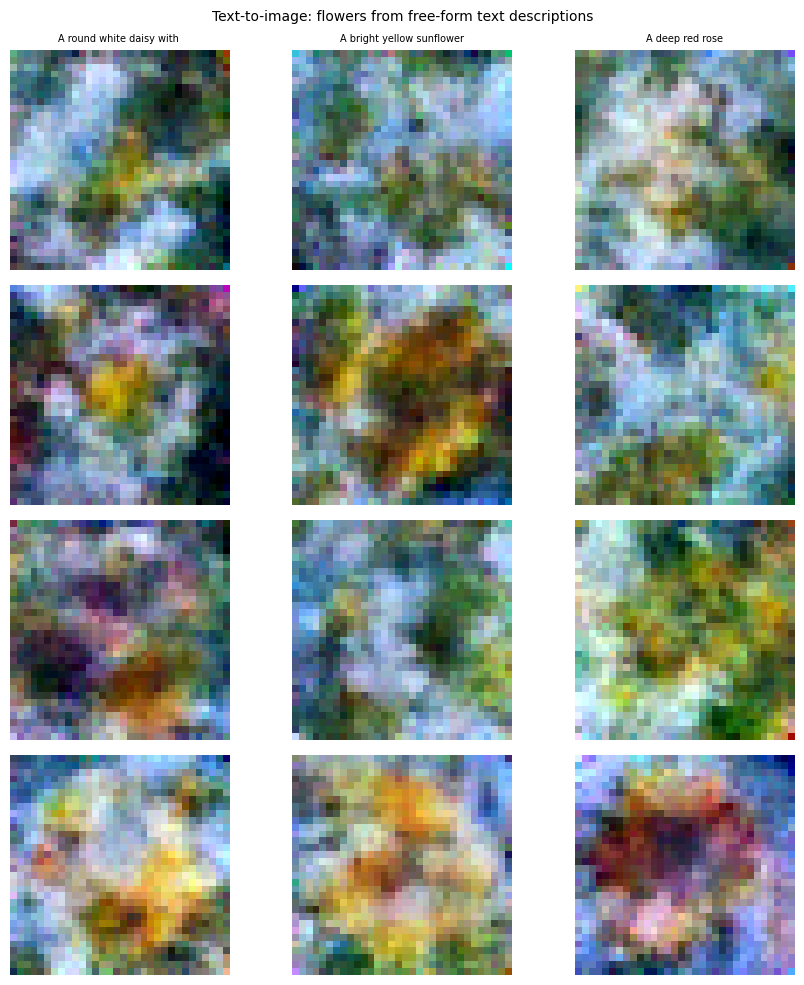

In [14]:
# Generate flowers from text descriptions

text_prompts = [
    'A round white daisy with a yellow center',
    'A bright yellow sunflower',
    'A deep red rose',
]

tokens = clip.tokenize(text_prompts).to(device)
with torch.no_grad():
    c_clip = clip_model.encode_text(tokens).float()
    c_clip = c_clip / c_clip.norm(dim=-1, keepdim=True)

w_values    = [0.0, 0.5, 1.0, 2.0]
n_prompts   = len(text_prompts)
n_w         = len(w_values)
n           = n_prompts * n_w

w_tensor = torch.tensor([v for v in w_values for _ in range(n_prompts)])
w_tensor = w_tensor[:, None, None, None].float().to(device)
c_rep    = c_clip.repeat(n_w, 1)

x_t = torch.randn(n, FLOWER_CH, FLOWER_SIZE, FLOWER_SIZE, device=device)

for i in range(T_FLOWERS - 1, -1, -1):
    t = torch.full((n,), i, device=device).float()
    x2 = x_t.repeat(2,1,1,1); t2 = t.repeat(2)
    c2 = c_rep.repeat(2, 1)
    m2 = torch.cat([torch.ones_like(c_rep), torch.zeros_like(c_rep)], dim=0)
    e2 = model_flowers(x2, t2, c2, m2)
    e_t = (1 + w_tensor) * e2[:n] - w_tensor * e2[n:]
    x_t = reverse_q_f(x_t, t, e_t)

fig, axes = plt.subplots(n_w, n_prompts, figsize=(9, 10))
for row in range(n_w):
    for col in range(n_prompts):
        idx = row * n_prompts + col
        axes[row, col].imshow(((x_t[idx]+1)/2).clamp(0,1).permute(1,2,0).cpu())
        if row == 0: axes[row, col].set_title(text_prompts[col][:25], fontsize=7)
        if col == 0: axes[row, col].set_ylabel(f'w = {w_values[row]}', fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('Text-to-image: flowers from free-form text descriptions', fontsize=10)
plt.tight_layout()
plt.show()

---

### Exercise: Try Your Own Text Prompts

Change the text prompts and run the cell again.
Some things to try:

- A more detailed description: `'A wilting yellow sunflower with drooping petals'`
- A color variation: `'A white rose'` or `'A pink daisy'`
- Something outside the training data: `'A purple tulip'`
- Compare w=0.0 (no guidance) vs w=2.0 (strong guidance) for the same prompt

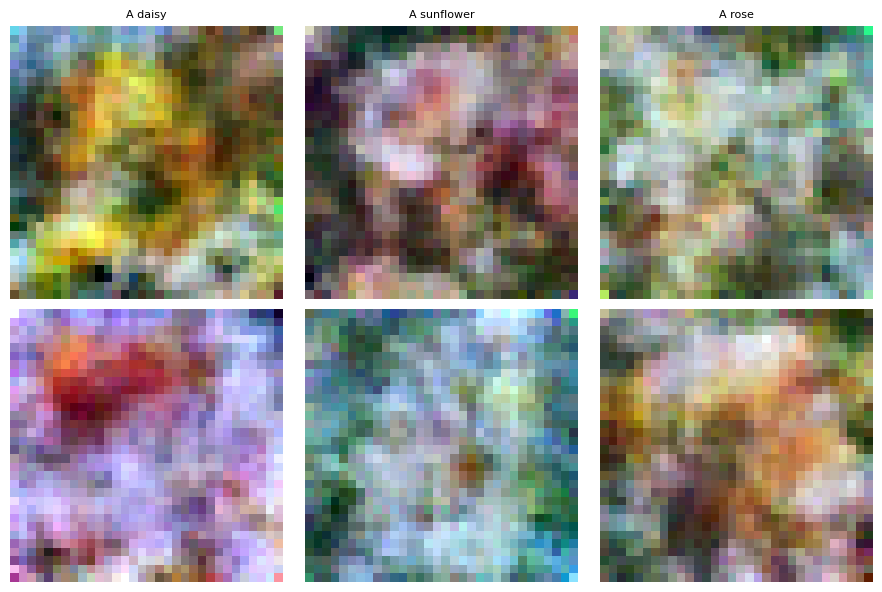

In [15]:
# TODO: change the text prompts and run this cell
my_prompts = [
    'A daisy',            # simple
    'A sunflower',        # simple
    'A rose',             # simple
    # 'A white rose',     # color variation
    # 'A purple tulip',   # outside training data
]

tokens = clip.tokenize(my_prompts).to(device)
with torch.no_grad():
    c_clip = clip_model.encode_text(tokens).float()
    c_clip = c_clip / c_clip.norm(dim=-1, keepdim=True)

n_p  = len(my_prompts)
w_ex = [0.5, 2.0]
n    = n_p * len(w_ex)
w_t  = torch.tensor([v for v in w_ex for _ in range(n_p)])[:, None, None, None].float().to(device)
c_r  = c_clip.repeat(len(w_ex), 1)

x_t = torch.randn(n, FLOWER_CH, FLOWER_SIZE, FLOWER_SIZE, device=device)
for i in range(T_FLOWERS - 1, -1, -1):
    t = torch.full((n,), i, device=device).float()
    x2 = x_t.repeat(2,1,1,1); t2 = t.repeat(2)
    c2 = c_r.repeat(2,1)
    m2 = torch.cat([torch.ones_like(c_r), torch.zeros_like(c_r)], dim=0)
    e2 = model_flowers(x2, t2, c2, m2)
    x_t = reverse_q_f(x_t, t, (1+w_t)*e2[:n] - w_t*e2[n:])

fig, axes = plt.subplots(len(w_ex), n_p, figsize=(3*n_p, 3*len(w_ex)))
if len(w_ex) == 1: axes = axes[None, :]
for row, w_val in enumerate(w_ex):
    for col in range(n_p):
        axes[row, col].imshow(((x_t[row*n_p+col]+1)/2).clamp(0,1).permute(1,2,0).cpu())
        if row == 0: axes[row, col].set_title(my_prompts[col][:25], fontsize=8)
        if col == 0: axes[row, col].set_ylabel(f'w={w_val}', fontsize=8)
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

---

## Wrapping Up

In this notebook you have:

- Added class conditioning and classifier-free guidance to UNetCFG
- Transferred weights from the 50-epoch model and fine-tuned with CFG
- Visualized the effect of guidance weight w on FashionMNIST generation
- Loaded CLIP and encoded text descriptions into 512-dimensional vectors
- Visualized cosine similarity between CLIP text encodings
- Generated flowers from free-form text using a CLIP-conditioned model

**Key points:**

- CFG does not change the U-Net architecture: it only adds two small context embed blocks.
  The same model handles both conditional and unconditional generation.
- The guidance weight w controls the tradeoff: higher w gives sharper class features
  but reduces diversity. w=0 is fully unconditional.
- Replacing one-hot class labels with CLIP encodings requires only one change:
  `c_embed_dim` goes from 10 (one-hot classes) to 512 (CLIP features).
  The rest of the architecture and training loop stay the same.
- Modern text-to-image systems (DALL-E, Stable Diffusion, Imagen) are all based
  on this same combination: diffusion model + CLIP-like text conditioning + CFG.

In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)